In [1]:
import numpy as np
from pyscf import gto, scf, mcscf, ao2mo
from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform
    )

from dmdm.interface import DMDM

In [6]:
import numpy as np
from pyscf import gto, scf, mcscf, ao2mo, mp

hartree_to_ev = 27.2114

# -------------------------
# USER SETTINGS
# -------------------------
basis = "sto-3g"
basis = 'aug-cc-pVDZ'          # change freely
num_active_orbitals = 4                  # number of active orbitals
num_active_electrons = 4               # number of active electrons
num_states = 5                # number of states

# -------------------------
# 1. Molecule
# -------------------------
mol = gto.M(
    # atom='''
    # O 0 0 0
    # H 0 -0.757 0.587
    # H 0  0.757 0.587
    # ''',
    atom=MoleculeData.molecules["H2O"]["coords"],
    basis=basis
)

# -------------------------
# 2. RHF
# -------------------------
mf = scf.RHF(mol).run()
mp2 = mp.MP2(mf).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(mp2)

# -------------------------
# 3. CASCI
# -------------------------
mc = mcscf.CASCI(mf, ncas=num_active_orbitals, nelecas=num_active_electrons)
mc.fcisolver.nroots = num_states
# mc.mo_coeff = natorbs

# IMPORTANT: unpack properly
e_tot, e_cas, ci, mo, mo_energy = mc.kernel()

print("\nCASCI total energies (e_tot):")
print(e_tot)

print("\nCASCI active energies (e_cas):")
print(e_cas)

# -------------------------
# 4. Integrals in MO basis
# -------------------------
# h1_ao = mf.get_hcore()
# h1_mo = mo.T @ h1_ao @ mo
h_mo, ecore = mc.get_h1eff()

g_mo = mc.get_h2eff()
g_mo = ao2mo.restore(1, g_mo, num_active_orbitals)

# -------------------------
# 5. Active-space slices
# -------------------------
# cas_slice = slice(mc.ncore, mc.ncore + ncas)

# h_mo = h1_mo[cas_slice, cas_slice]
# g_mo = eri_mo[cas_slice, cas_slice, cas_slice, cas_slice]

# -------------------------
# 6. RDM reconstruction
# -------------------------
rdm_active_energies = []

for i in range(num_states):
    print(f"Processing state {i}")

    ci_vec = ci[i]

    # IMPORTANT: use consistent RDM call
    rdm1, rdm2, rdm3, rdm4 = mc.fcisolver.make_rdm1234(ci_vec, num_active_orbitals, num_active_electrons)
    # rdm1, rdm2 = mc.fcisolver.make_rdm12(ci_vec, ncas, nelecas)

    # Energy reconstruction (ACTIVE SPACE ONLY)
    e1 = np.einsum('pq,pq', h_mo, rdm1)
    e2 = 0.5 * np.einsum('pqrs,pqrs', g_mo, rdm2)

    e_active = e1 + e2
    rdm_active_energies.append(e_active)

rdm_active_energies = np.array(rdm_active_energies)

# -------------------------
# 7. Compare ACTIVE energies (correct comparison!)
# -------------------------
print("\nRDM reconstructed active energies:")
print(rdm_active_energies)

print("\nDifference (RDM - e_cas):")
print(rdm_active_energies - e_cas)

# -------------------------
# 8. (Optional) Reconstruct TOTAL energies
# -------------------------
# Core energy is constant → extract from ground state
E_core = e_tot[0] - e_cas[0]

rdm_total_energies = rdm_active_energies + E_core

print("\nReconstructed TOTAL energies:")
print(rdm_total_energies)

print("\nDifference (RDM total - e_tot):")
print(rdm_total_energies - e_tot)

# -------------------------
# 9. Excitation energies (eV)
# -------------------------
exc_energies = (rdm_active_energies - rdm_active_energies[0]) * hartree_to_ev

print("\nExcitation energies (eV):")
print(exc_energies[1:])

converged SCF energy = -76.0390921843415
E(RMP2) = -76.2624063714749  E_corr = -0.223314187133456
E(SCS-RMP2) = -76.2576615002881  E_corr = -0.218569315946653

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -76.0391045346112  E(CI) = -6.10740202695830  S^2 = 0.0000000
CASCI state   1  E = -75.6827978529691  E(CI) = -5.75109534531619  S^2 = 2.0000000
CASCI state   2  E = -75.6785939654529  E(CI) = -5.74689145780003  S^2 = 0.0000000
CASCI state   3  E = -75.6256954909972  E(CI) = -5.69399298334429  S^2 = 2.0000000
CASCI state   4  E = -75.6248585975569  E(CI) = -5.69315608990401  S^2 = 0.0000000

CASCI total energies (e_tot):
[-76.03910453 -75.68279785 -75.67859397 -75.62569549 -75.6248586 ]

CASCI active energies (e_cas):
[-6.10740203 -5.75109535 -5.74689146 -5.69399298 -5.69315609]
Processing state 0
Processing state 1
Processing state 2
Processing state 3
Processing state 4

RDM re

In [7]:
# Pick ground state
i = 0
ci_vec = ci[i]
rdm1, rdm2, rdm3, rdm4 = mc.fcisolver.make_rdm1234(ci_vec, num_active_orbitals, num_active_electrons)



# -------------------------
# DMDM
# -------------------------
dmdm = DMDM(
    h_mo,
    g_mo,
    0,
    num_active_orbitals,
    0,
    num_active_electrons,
    rdm1,
    rdm2=rdm2,
    rdm3=rdm3,
    rdm4=rdm4,
)

# -------------------------
# Dipole integrals (correct)
# -------------------------
x_ao, y_ao, z_ao = mol.intor('int1e_r', comp=3)


cas_slice = slice(mc.ncore, mc.ncore + num_active_orbitals)


mo = mc.mo_coeff

# x_mo = mo.T @ x_ao @ mo
# y_mo = mo.T @ y_ao @ mo
# z_mo = mo.T @ z_ao @ mo


# x_cas = x_mo[cas_slice, cas_slice]
# y_cas = y_mo[cas_slice, cas_slice]
# z_cas = z_mo[cas_slice, cas_slice]

# MO_DM = [x_cas, y_cas, z_cas]

C_cas = mo[:, cas_slice]

x_cas = one_electron_integral_transform(C_cas, x_ao)
y_cas = one_electron_integral_transform(C_cas, y_ao)
z_cas = one_electron_integral_transform(C_cas, z_ao)

MO_DM = [x_cas, y_cas, z_cas]

# -------------------------
# DMDM results
# -------------------------
exc_energies_ev_dmdm = dmdm.get_excitation_energies() * hartree_to_ev
osc_strengths = dmdm.get_oscillator_strength(MO_DM)


idx, max(abs(grad active)): 15 2.844719361982836e-15
Smallest Hessian eigenvalue: (0.3593415606568656+0j)
Smallest diagonal element in the metric: 0.9999846697444696


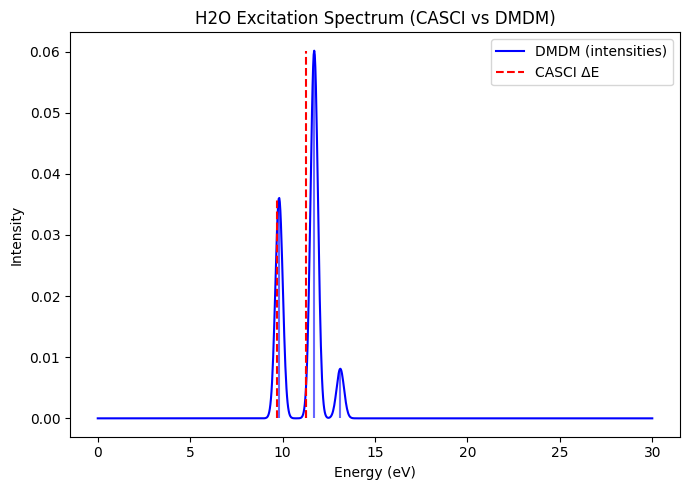

In [8]:
import matplotlib.pyplot as plt
import numpy as np

hartree_to_ev = 27.2114

# -------------------------
# DMDM results (example)
# -------------------------
# exc_energies_dmdm = dmdm.get_excitation_energies()[:num_states-1] * hartree_to_ev
# osc_strengths = dmdm.get_oscillator_strength(MO_DM)[:num_states-1]

# Prepend 0 eV for ground state
exc_energies_dmdm_aligned = np.concatenate(([0.0], exc_energies_ev_dmdm[:num_states-1]))
osc_strengths_aligned = np.concatenate(([0.0], osc_strengths[:num_states-1]))

# Optional: classical CASCI excitation energies for comparison
exc_casci = (e_cas - e_cas[0]) * hartree_to_ev

# -------------------------
# Build Gaussian stick spectrum
# -------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

x = np.linspace(0, 30, 1000)  # energy axis in eV
sigma = 0.2                   # broadening

spectrum_dmdm = np.zeros_like(x)
for e, f in zip(exc_energies_dmdm_aligned, osc_strengths_aligned):
    spectrum_dmdm += f * gaussian(x, e, sigma)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(7,5))

# DMDM stick spectrum
plt.plot(x, spectrum_dmdm, label="DMDM (intensities)", color='blue')

# Optional: plot sticks
plt.vlines(exc_energies_dmdm_aligned, 0, osc_strengths_aligned, color='blue', alpha=0.6)

# CASCI reference (sticks only)
plt.vlines(exc_casci, 0, osc_strengths_aligned, color='red', linestyles='dashed', label='CASCI ΔE')

plt.xlabel("Energy (eV)")
plt.ylabel("Intensity")
plt.title("H2O Excitation Spectrum (CASCI vs DMDM)")
plt.legend()
plt.tight_layout()
plt.show()